In [1]:
# Bayesian MMM

In [2]:
# 1. Load Data

In [3]:
from importlib.metadata import distribution
from os import times

import numpy as np
import pandas as pd
import os

from matplotlib.testing.jpl_units import day
from pytensor.link.c.lazylinker_c import actual_version
from streamlit import dataframe
from supabase import create_client, Client
from dotenv import load_dotenv
import datetime as dt


def extract_data_supabase():
    # Read the environment variables from .env
    load_dotenv(dotenv_path="../.env")

    # initialise Supabase client side
    url = os.environ.get("SUPABASE_URL")
    key = os.environ.get("SUPABASE_KEY")

    supabase = create_client(url, key)

    # extract data from Supabase
    response = supabase.table("marketing_spend_weekly").select("*").execute()

    # convert the response to dataframe
    dataframe_raw = pd.DataFrame(response.data)
    dataframe_raw["date"] = pd.to_datetime(dataframe_raw["date"], format="%Y-%m-%d")
    dataframe_raw = dataframe_raw.sort_values(by="date").reset_index(drop=True)

    return dataframe_raw

In [4]:
df = extract_data_supabase()
df.head(3)

,date,PPC_Brand_Spend,PPC_Generic_Spend,Display_Spend,Social_Spend,TV_Spend,OOH_Spend,Meta_Spend,Yahoo_Spend,competitor_spend,google_trend_competitor,opportunities,sales
0,2020-01-06,33606.667083,12359.075216,9986.110339,7553.655263,23057.166184,12462.531065,5376.929177,2276.638237,52119.484639,48.902186,2169.368536,258.949354
1,2020-01-13,24275.884049,14434.738310,15002.644018,8079.099846,20604.238251,11626.697707,5276.868373,1949.054037,45134.452504,55.010903,2450.723580,303.521532
2,2020-01-20,24797.574326,12666.330243,13383.768500,8005.664941,27517.645795,12093.366880,4735.128755,2502.308650,47586.047249,41.571042,2279.740794,278.043856


In [5]:
# 2. EDA

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   date                     260 non-null    datetime64[us]
 1   PPC_Brand_Spend          260 non-null    float64       
 2   PPC_Generic_Spend        260 non-null    float64       
 3   Display_Spend            260 non-null    float64       
 4   Social_Spend             260 non-null    float64       
 5   TV_Spend                 260 non-null    float64       
 6   OOH_Spend                260 non-null    float64       
 7   Meta_Spend               260 non-null    float64       
 8   Yahoo_Spend              260 non-null    float64       
 9   competitor_spend         260 non-null    float64       
 10  google_trend_competitor  260 non-null    float64       
 11  opportunities            260 non-null    float64       
 12  sales                    260 non-null    float6

In [7]:
df.describe()

,date,PPC_Brand_Spend,PPC_Generic_Spend,Display_Spend,Social_Spend,TV_Spend,OOH_Spend,Meta_Spend,Yahoo_Spend,competitor_spend,google_trend_competitor,opportunities,sales
count,260,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000
mean,2022-06-30 12:00:00,19735.899191,13136.112552,8793.107400,6595.066409,28527.635323,11120.996064,8220.952419,2822.098502,45441.832747,50.662365,2341.239982,280.536179
min,2020-01-06 00:00:00,8558.177532,5282.778603,3656.354172,2984.425350,12365.716302,5061.183000,3254.041378,1264.525200,34908.896055,20.374122,1761.834301,205.206107
25%,2021-04-03 06:00:00,13964.194713,9501.541423,6344.030735,4591.337161,20453.940395,8228.523552,5615.895369,1969.168915,42087.705866,41.911625,2161.955703,257.128199
50%,2022-06-30 12:00:00,18794.439572,12581.488002,8302.158850,6433.460558,27379.206092,10974.735370,7534.764133,2761.226352,45137.388839,51.618656,2355.327330,280.554883
75%,2023-09-26 18:00:00,24400.922530,15803.095511,10698.147677,7943.224957,35355.252909,13393.190596,10177.572763,3482.626293,47701.007667,59.951868,2528.691974,302.746704
max,2024-12-23 00:00:00,52458.421412,42534.503106,22318.497274,16330.085642,64686.420827,27568.474234,29026.416504,8603.180065,63565.262244,80.390182,2960.950661,350.582216
std,NaN,7106.512196,5107.018934,3146.915683,2436.849771,9654.987882,3568.798428,3532.705466,1034.607915,4679.550568,12.106800,255.896876,31.733694


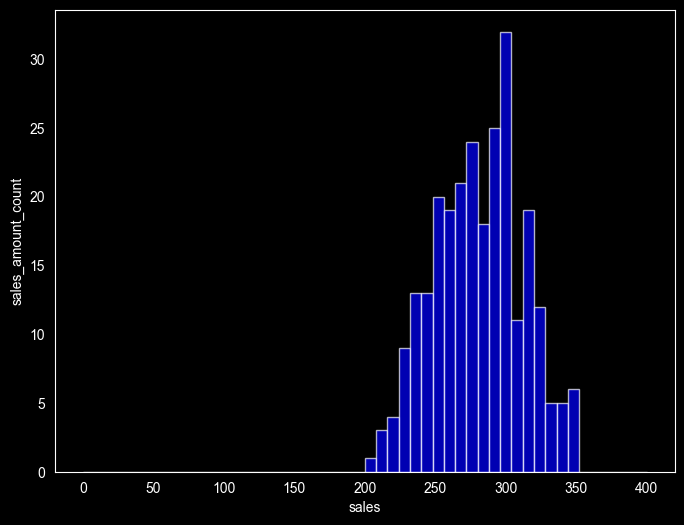

In [8]:
# plot sales distribution
# sales is between 200 and 350
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.hist(x=df["sales"], bins=50, range=(0, 400), color="blue", alpha=0.7)
plt.grid(False)
plt.xlabel("sales")
plt.ylabel("sales_amount_count")
plt.show()

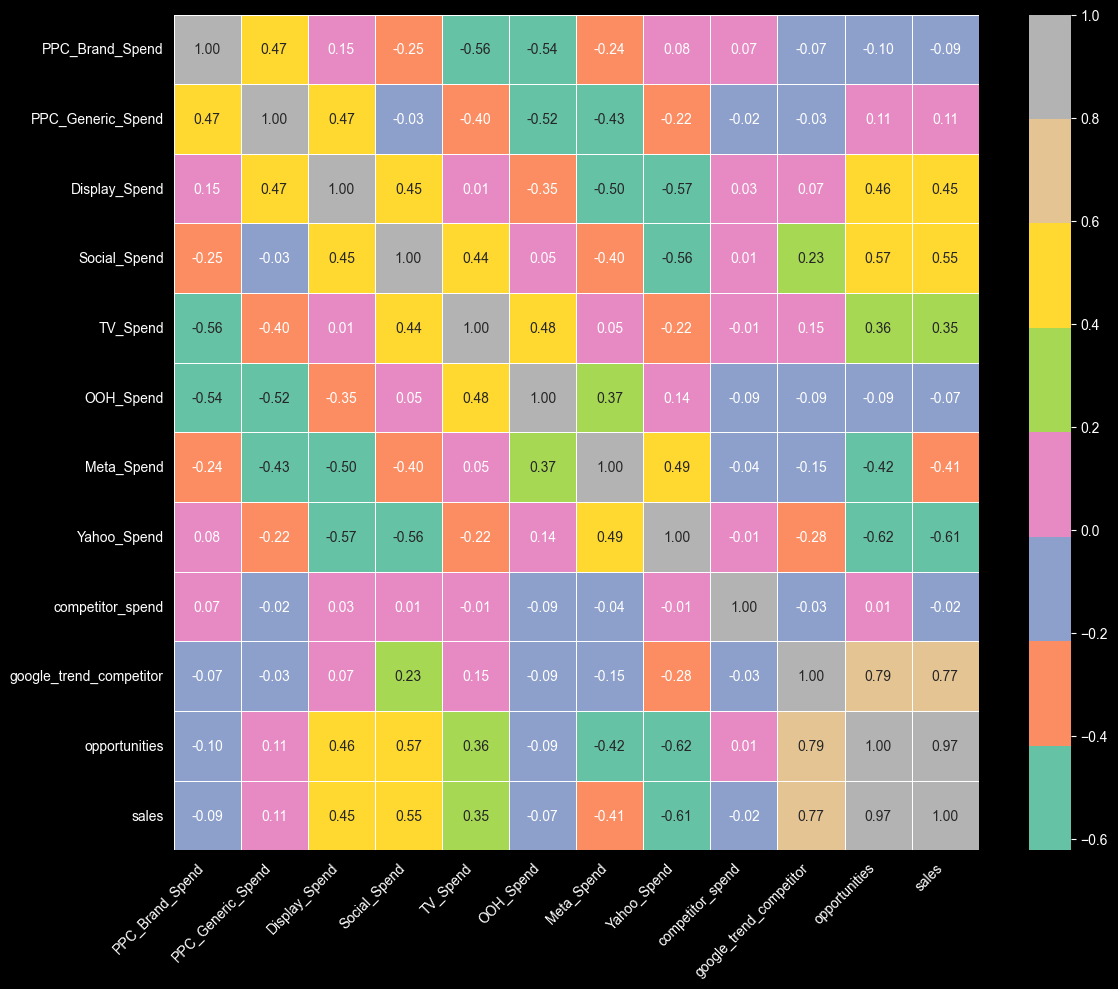

In [9]:
# create correlation matrix
import seaborn as sns

df_n = df.select_dtypes(include=np.number)
df_n2 = pd.DataFrame(df_n)
corr_matrix = df_n2.corr().astype(float)

plt.figure(figsize=(12, 10))

sns.heatmap(
    data=corr_matrix,
    xticklabels=corr_matrix.columns,
    yticklabels=corr_matrix.columns,
    annot=True,
    cmap="Set2",
    linewidths=0.5,
    fmt=".2f",
    annot_kws={"size": 10},
)
plt.xticks(rotation=45, ha="right")

plt.tight_layout()

In [10]:
# as we build bayesian MMM, we won't group the channels that have medium correlation. We can't find out which channel has higher beta(coefficient). In Bayesian MMM, we set Priors based on previous performance. e.g. Meta is 20% higher conversion than Yahoo. we will set Meta beta = 3.6 Yahoo beta = 3
corr_pairs = corr_matrix.unstack()
corr_pairs = corr_pairs[corr_pairs != 1]
high_corr = (
    corr_pairs[corr_pairs >= 0.45].drop_duplicates().sort_values(ascending=False)
)
print(high_corr)

opportunities            sales                0.969850
google_trend_competitor  opportunities        0.787109
                         sales                0.773949
Social_Spend             opportunities        0.573315
                         sales                0.552124
Meta_Spend               Yahoo_Spend          0.485949
TV_Spend                 OOH_Spend            0.481392
PPC_Generic_Spend        Display_Spend        0.474575
PPC_Brand_Spend          PPC_Generic_Spend    0.474167
Display_Spend            opportunities        0.457197
                         Social_Spend         0.453981
dtype: float64


In [11]:
# 3. Feature Engineering

In [12]:
def data_process(dataset: pd.DataFrame):
    spend_cols = [
        x
        for x in dataset.columns
        if x.lower().endswith("_spend") and x != "competitor_spend"
    ]

    # check columns name end with Spend or not
    # or use
    # spend_cols = df.columns[df.columns.str.endswith('_Spend')].tolist()
    # spend_cols

    spend_per_channel = dataset[spend_cols].sum(axis=0)
    spend_per_channel_pct = spend_per_channel / spend_per_channel.sum(axis=0)

    # specify sigma parameter per channel
    n_channels = 8
    prior_sigma = n_channels * spend_per_channel_pct
    return prior_sigma.tolist()

In [13]:
prior_sigma_list = data_process(df)
prior_sigma_list

[1.5955958886318946,
 1.0620203811052364,
 0.7108997608380688,
 0.533193889262564,
 2.306384786042627,
 0.8991034776563848,
 0.6646425254195637,
 0.2281592910436607]

In [14]:
# 4. Model Specification

In [15]:
# from pymc_marketing.mmm import GeometricAdstock, LogisticSaturation
# from pymc_marketing.mmm.multidimensional import MMM

In [16]:
# def mmm_model(dataset: pd.DataFrame, prior_sigma: float):
#     X = df.drop('sales', axis=1)
#     y = df['sales']
#
#     dummy_model = MMM(
#         date_column="",
#         channel_columns=[""],
#         adstock=GeometricAdstock(l_max=4),
#         saturation=LogisticSaturation(),
#     )
#     return dummy_model.default_model_config


In [17]:
# dummy_model_dict = mmm_model(df,prior_sigma_list)
# dummy_model_dict

In [18]:
import pymc as pm
from pymc_marketing.mmm import GeometricAdstock, LogisticSaturation, HillSaturation
from pymc_marketing.mmm.multidimensional import MMM
from pymc_marketing.prior import Prior
import arviz as az


def mmm_model_prior(dataset: pd.DataFrame, prior_sigma: float):
    import os

    os.environ["PATH"] += os.pathsep + r"C:\msys64\mingw64\bin"

    alpha_list = [1, 1, 1, 1, 3, 3, 1, 1]
    beta_list = [3, 3, 3, 3, 1, 1, 3, 3]

    y = dataset["opportunities"].copy()
    y.name = "y"
    X = dataset.drop("opportunities", axis=1)

    my_model_config = {
        "intercept": Prior("Normal", mu=0.5, sigma=2),
        "saturation_beta": Prior("HalfNormal", sigma=prior_sigma, dims="channel"),
        "gamma_control": Prior("Normal", mu=0, sigma=0.5, dims="control"),
        "gamma_fourier": Prior("Laplace", mu=0, b=0.5, dims="fourier_mode"),
        "adstock_alpha": Prior(
            "Beta", alpha=alpha_list, beta=beta_list, dims="channel"
        ),
        "saturation_slope": Prior("Gamma", alpha=3, beta=1, dims="channel"),
        "likelihood": Prior("Normal", sigma=Prior("HalfNormal", sigma=6)),
    }

    my_sampler_config = {
        "progressbar": True,  # display the status bar
        "draws": 1000,  # sampling 1000 times
        "chains": 4,  # 4 chains
        "nuts_sampler": "numpyro",
    }

    mmm = MMM(
        model_config=my_model_config,
        sampler_config=my_sampler_config,
        date_column="date",
        target_column="y",
        adstock=GeometricAdstock(l_max=8),
        saturation=HillSaturation(),
        channel_columns=[
            "PPC_Brand_Spend",
            "PPC_Generic_Spend",
            "Display_Spend",
            "Social_Spend",
            "TV_Spend",
            "OOH_Spend",
            "Meta_Spend",
            "Yahoo_Spend",
        ],
        control_columns=["competitor_spend", "google_trend_competitor"],
        yearly_seasonality=2,
    )

    mmm.build_model(X, y)
    mmm.add_original_scale_contribution_variable(
        var=[
            "channel_contribution",
            "control_contribution",
            "intercept_contribution",
            "yearly_seasonality_contribution",
            "y",
        ]
    )
    try:
        display(pm.model_to_graphviz(mmm.model))
    except NameError:
        pass

    # Generate prior predictive samples
    mmm.sample_prior_predictive(X, y, samples=2_000)
    mmm.plot.prior_predictive()

    # Custom plot for prior predictive checks
    fig, ax = plt.subplots(figsize=(10, 6))
    for i, hdi_prob in enumerate([0.94, 0.5]):
        az.plot_hdi(
            x=mmm.model.coords["date"],
            y=mmm.idata["prior"]["y_original_scale"].unstack().transpose(..., "date"),
            smooth=False,
            color="C0",
            hdi_prob=hdi_prob,
            fill_kwargs={"alpha": 0.3 + i * 0.1, "label": f"{hdi_prob: .0%} HDI"},
            ax=ax,
        )
    sns.lineplot(
        data=dataset, x="date", y="sales", color="black", label="observed", ax=ax
    )
    ax.legend(loc="upper left")
    ax.set(xlabel="date", ylabel="sales")
    ax.set_title("Prior Predictive Checks", fontsize=18, fontweight="bold")
    return X, y, mmm, fig

C:\Users\ipnga\PycharmProjects\bayesian-mmm\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\ipnga\PycharmProjects\bayesian-mmm\.venv\Lib\site-packages\pymc_extras\prior.py:822: UserWarning: Implicit conversion of array-like parameter alpha to DataArray with dims ('channel',). Use DataArray with explicit dims to avoid this warning
  return _param_value_with_dims(param, value, dims=self.dims)
C:\Users\ipnga\PycharmProjects\bayesian-mmm\.venv\Lib\site-packages\pymc_extras\prior.py:822: UserWarning: Implicit conversion of array-like parameter beta to DataArray with dims ('channel',). Use DataArray with explicit dims to avoid this warning
  return _param_value_with_dims(param, value, dims=self.dims)
C:\Users\ipnga\PycharmProjects\bayesian-mmm\.venv\Lib\site-packages\pymc_extras\prior.py:822: UserWarning: Implicit conversion of array-like parameter sigma to DataArray with dims ('channel',). Use DataArray with explicit dims to avoid this warning
  return _param_value_with_dims(param, value, dims=self.dims)


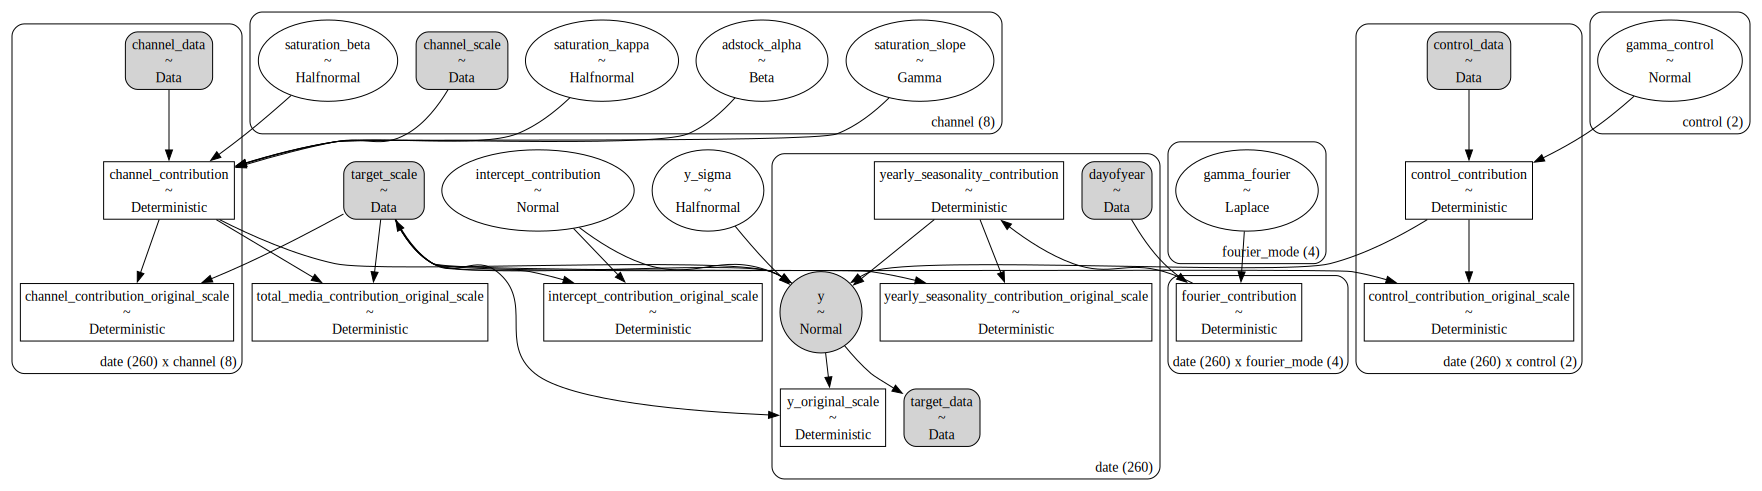

Sampling: [adstock_alpha, gamma_control, gamma_fourier, intercept_contribution, saturation_beta, saturation_kappa, saturation_slope, y, y_sigma]


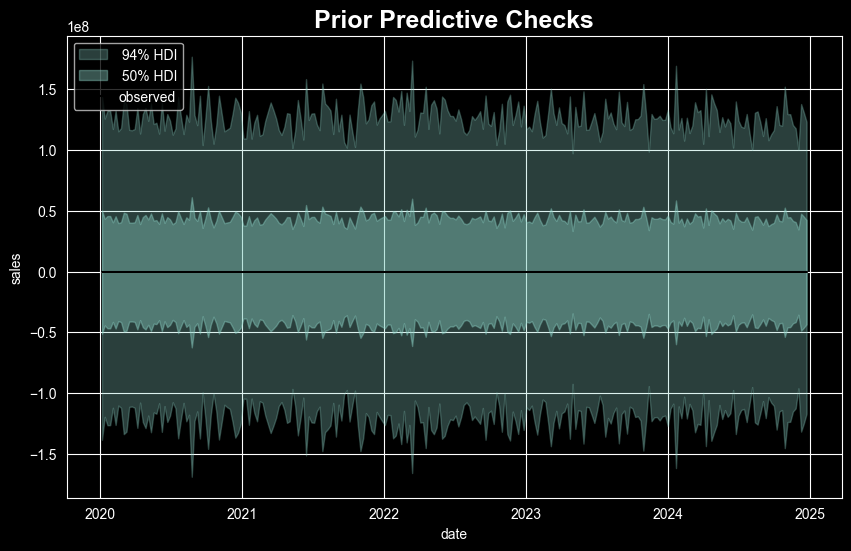

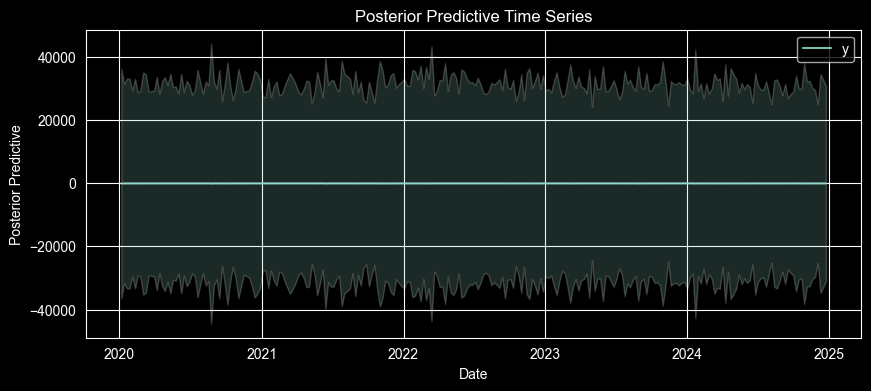

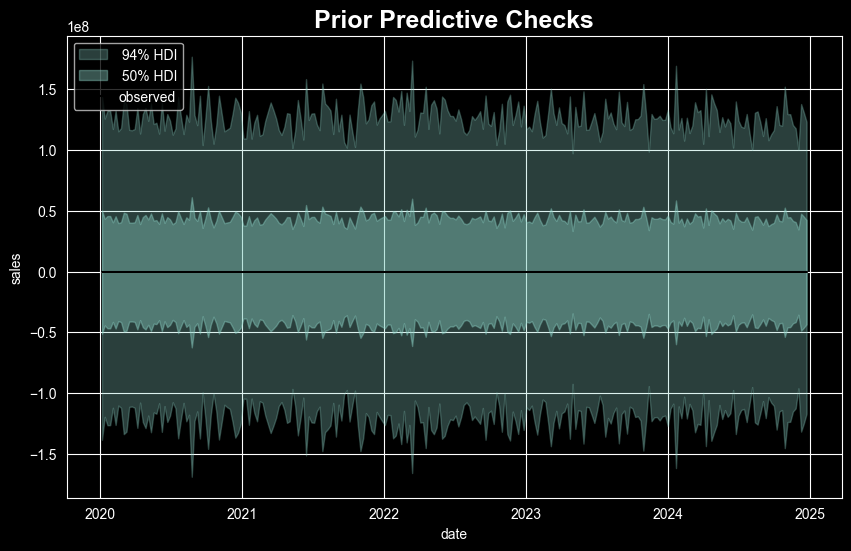

In [19]:
X, y, mmm, prior_predictive_check = mmm_model_prior(df, prior_sigma_list)
prior_predictive_check

In [20]:
# 5. Model Fitting

In [21]:
import numpy as np
import pandas as pd
from pymc_marketing.mmm.multidimensional import MMM
import arviz as az
import matplotlib.pyplot as plt


def mmm_model_train(x: pd.DataFrame, y: pd.Series, mmm: MMM):
    rng = np.random.default_rng(42)
    # train model
    mmm.fit(
        X=x,
        y=y,
        chains=4,
        draws=1_000,
        target_accept=0.8,
        random_seed=rng,
    )

    print("training completed")
    print(f"Model was trained using the {mmm.saturation.__class__.__name__} function")
    print(f"and the {mmm.adstock.__class__.__name__} function")

    # model diagnostics
    diverging_count = mmm.idata["sample_stats"]["diverging"].sum().item()
    print(f"Model Diagnostics : {diverging_count}")

    summary_df = az.summary(
        data=mmm.fit_result,
        var_names=[
            "adstock_alpha",
            "gamma_control",
            "gamma_fourier",
            "intercept_contribution",
            "saturation_beta",
            "saturation_slope",
            "y_sigma",
        ],
    )

    # plotting the trace for parameters
    trace = az.plot_trace(
        data=mmm.fit_result,
        var_names=[
            "adstock_alpha",
            "gamma_control",
            "gamma_fourier",
            "intercept_contribution",
            "saturation_beta",
            "saturation_slope",
            "y_sigma",
        ],
        compact=True,
        backend_kwargs={"figsize": (12, 10), "layout": "constrained"},
    )

    trace_graph = plt.gcf()  # gcf = Get Current Figure
    trace_graph.suptitle("Model Trace", fontsize=18, fontweight="bold")
    return summary_df, trace_graph

Compiling.. :   0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

Compiling.. :   0%|          | 0/2000 [00:00<?, ?it/s]


  0%|          | 0/2000 [00:00<?, ?it/s]


Running chain 1:   0%|          | 0/2000 [00:02<?, ?it/s]

Running chain 2:   0%|          | 0/2000 [00:02<?, ?it/s]


Running chain 1:   5%|▌         | 100/2000 [00:19<05:13,  6.06it/s]

Running chain 2:   5%|▌         | 100/2000 [00:20<05:44,  5.52it/s]


Running chain 0:  10%|█         | 200/2000 [00:42<06:10,  4.86it/s]


Running chain 3:  10%|█         | 200/2000 [00:43<06:07,  4.90it/s]

Running chain 0:  15%|█▌        | 300/2000 [01:05<06:10,  4.59it/s]


Running chain 3:  15%|█▌        | 300/2000 [01:06<06:10,  4.59it/s]

Running chain 0:  20%|██        | 400/2000 [01:30<06:05,  4.37it/s]


Running chain 3:  20%|██        | 400/2000 [01:31<06:07,  4.36it/s]

Running chain 0:  25%|██▌       | 500/2000 [01:54<05:52,  4.26it/s]


Running chain 3:  25%|██▌       | 500/2000 [01:56<05:55, 

C:\Users\ipnga\PycharmProjects\bayesian-mmm\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

training completed
Model was trained using the HillSaturation function
and the GeometricAdstock function
Model Diagnostics : 94


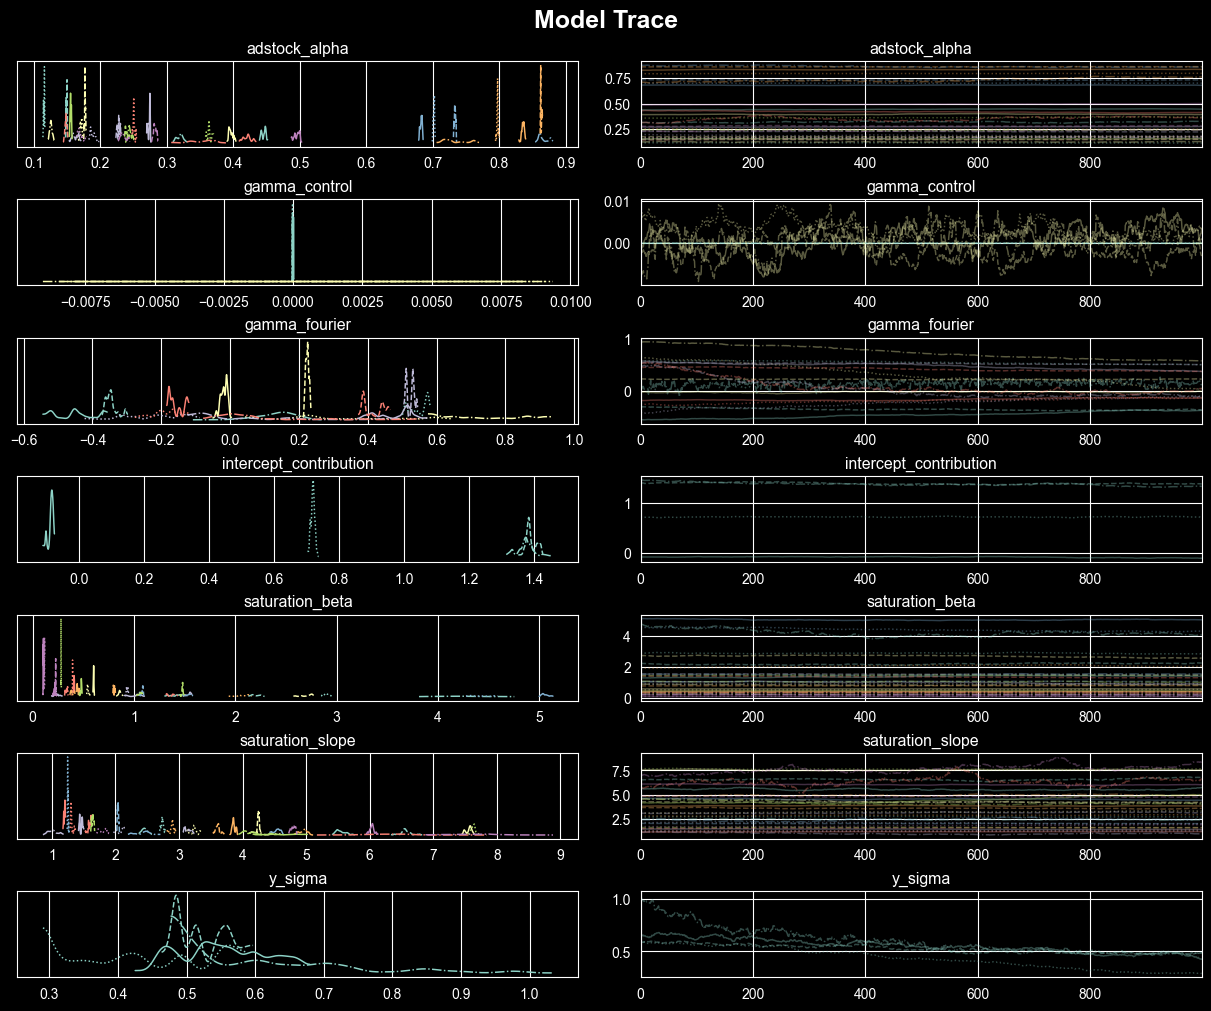

In [22]:
mmm_summary, trace_fig = mmm_model_train(X, y, mmm)

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import arviz as az
from pymc_marketing.mmm.multidimensional import MMM
import warnings


def mmm_model_predict(mmm: MMM, x: pd.DataFrame, df: pd.DataFrame):
    warnings.filterwarnings("ignore", category=UserWarning)

    rng = np.random.default_rng(42)
    mmm.sample_posterior_predictive(X=x, random_seed=rng)

    # 1) posterior predictive plot: plot the predicted sales range(from model training) with 94% HDI.
    # with the observed sales(actual sales). if the black line is within the range, it means the model is reliable.
    fig, axes_pp = mmm.plot.posterior_predictive(
        var=["y_original_scale"], hdi_prob=0.94
    )
    sns.lineplot(
        data=df,
        x="date",
        y="sales",
        color="black",
        label="Observed",
        ax=axes_pp.flatten()[0],
    )

    # multiply scaled contribution and _target, does it equal to original?
    # np.testing.assert_allclose(
    #     mmm.idata['posterior']['channel_contribution'].sel(channel='PPC_Brand_Spend') * mmm.scalers['_target'],
    #     mmm.idata['posterior']['channel_contribution_original_scale'].sel(channel='PPC_Brand_Spend'),
    #     )
    #
    # np.testing.assert_allclose(
    #     mmm.idata['posterior']['channel_contribution'].sel(channel='Display_Spend') * mmm.scalers['_target'],
    #     mmm.idata['posterior']['channel_contribution_original_scale'].sel(channel='Display_Spend'),
    #     )
    #
    # np.testing.assert_allclose(
    # mmm.idata["posterior"]["intercept_contribution"] * mmm.scalers["_target"],
    # mmm.idata["posterior"]["intercept_contribution_original_scale"],
    # )

    # 2) Contributions Over Time: ploting all contributions into one chart
    # Plot Channel Contribution (scaled)
    fig1, axes1 = mmm.plot.contributions_over_time(
        var=["channel_contribution"], hdi_prob=0.94
    )

    # Plot Channel Contribution (original)
    fig2, axes2 = mmm.plot.contributions_over_time(
        var=["channel_contribution_original_scale"], hdi_prob=0.94
    )

    fig3, axes3 = mmm.plot.contributions_over_time(
        var=[
            "channel_contribution_original_scale",
            "control_contribution_original_scale",
            "intercept_contribution_original_scale",
            "yearly_seasonality_contribution_original_scale",
        ],
        dims={
            "channel": [
                "PPC_Brand_Spend",
                "PPC_Generic_Spend",
                "Display_Spend",
                "Social_Spend",
                "TV_Spend",
                "OOH_Spend",
                "Meta_Spend",
                "Yahoo_Spend",
            ]
        },
        hdi_prob=0.94,
    )

    axes3 = axes3.flatten()

    for ax in axes3:
        legend = ax.get_legend()
        if legend is not None:
            # legend.set_bbox_to_anchor((0.5, -0.1))
            ax.legend(loc="upper left", bbox_to_anchor=(1.05, 1), fontsize="small")

    plt.gcf().savefig("mmm_contributions.png", bbox_inches="tight")
    plt.show()

    # 3) waterfall & mean contribution: understand the mean contribution per channel over times
    mmm_waterfall = mmm.plot.waterfall_components_decomposition()
    mmm_contribution = mmm.compute_mean_contributions_over_time()

    # plotting a chart to display the posterior distribution and actual contribution
    fig4, ax4 = plt.subplots(
        nrows=2,
        ncols=1,
        sharex=True,
        sharey=True,
        figsize=(12, 7),
        layout="constrained",
    )
    # 4) Media effects / Parameters
    alpha_var = (
        "adstock_alpha"
        if "adstock_alpha" in mmm.idata["posterior"].data_vars
        else "adstock_alpha"
    )
    # adstock alpha posterior: higher alpha(close to 1) means the lagging effect last longer.
    # set ref_val to compare the model estimated lagging effect range
    az.plot_posterior(
        mmm.idata["posterior"],
        var_names=["adstock_alpha"],
        ref_val={
            "adstock_alpha": [
                {"channel": "PPC_Brand_Spend", "ref_val": 0.4},
                {"channel": "Display_Spend", "ref_val": 0.2},
            ],
        },
        ax=ax4,
    )

    fig4.suptitle("Adstock Alpha Posterior", fontsize=18, fontweight="bold")

    # 5) Saturation Lambda/slope Posterior
    # plot saturation per channel
    fig5, ax5 = plt.subplots(
        nrows=2,
        ncols=1,
        sharex=True,
        sharey=True,
        figsize=(12, 7),
        layout="constrained",
    )

    slope_var = (
        "saturation_slope"
        if "saturation_slope" in mmm.idata["posterior"].data_vars
        else "saturation_slope"
    )

    az.plot_posterior(
        mmm.idata["posterior"],
        var_names=[slope_var],
        ref_val={
            slope_var: [
                {"channel": "PPC_Brand_Spend", "ref_val": 4.0},
                {"channel": "Display_Spend", "ref_val": 3.0},
            ],
        },
        ax=ax5,
    )

    fig5.suptitle("Saturation Lambda Posterior", fontsize=18, fontweight="bold")

    # 6) Sensitivity Analysis: if the line (channel) still increase after 1.0, it hasn't reached to saturation yet.
    sweeps = np.linspace(0, 1.5, 12)
    mmm.sensitivity.run_sweep(
        sweep_values=sweeps,
        var_input="channel_data",
        var_names="channel_contribution_original_scale",
        extend_idata=True,
    )

    # Plot sensitivity analysis
    ax6 = mmm.plot.sensitivity_analysis(
        xlabel="Sweep multiplicative",
        ylabel="Total contribution over training period",
        hue_dim="channel",
        x_sweep_axis="relative",
    )
    ax6.axvline(1.0, color="black", linestyle="--", linewidth=1)
    return mmm_waterfall, mmm_contribution

In [24]:
# mmm.idata['posterior']

Sampling: [y]


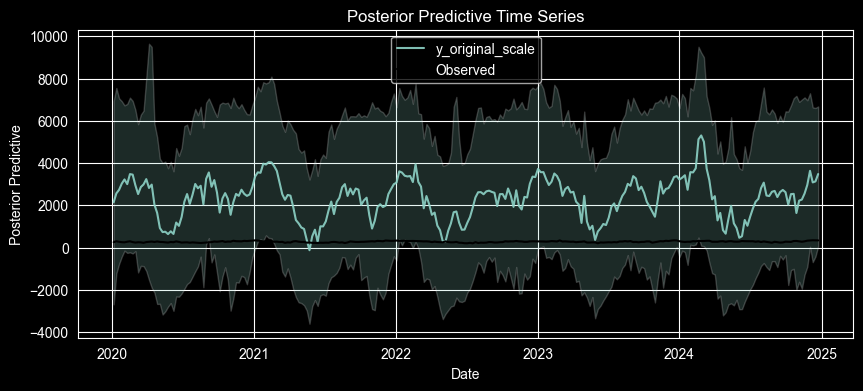

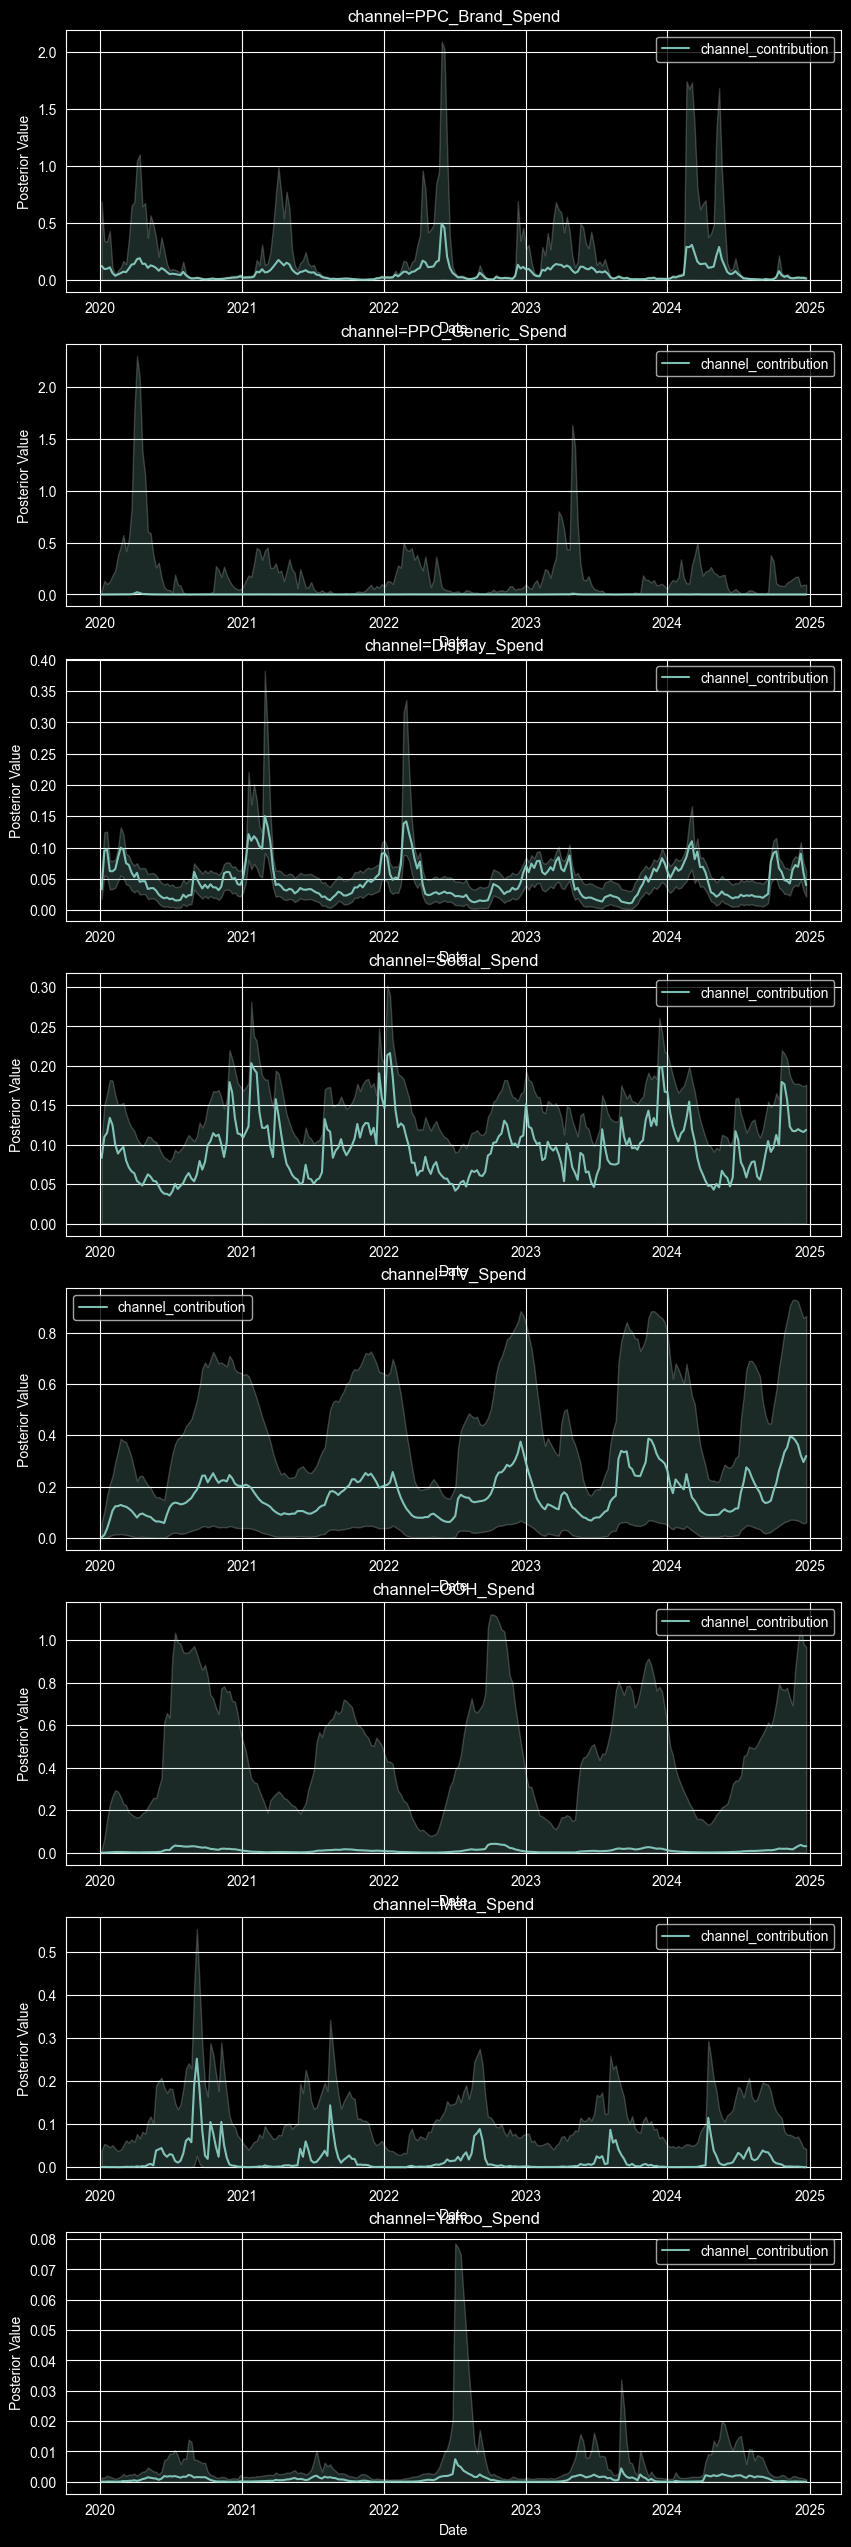

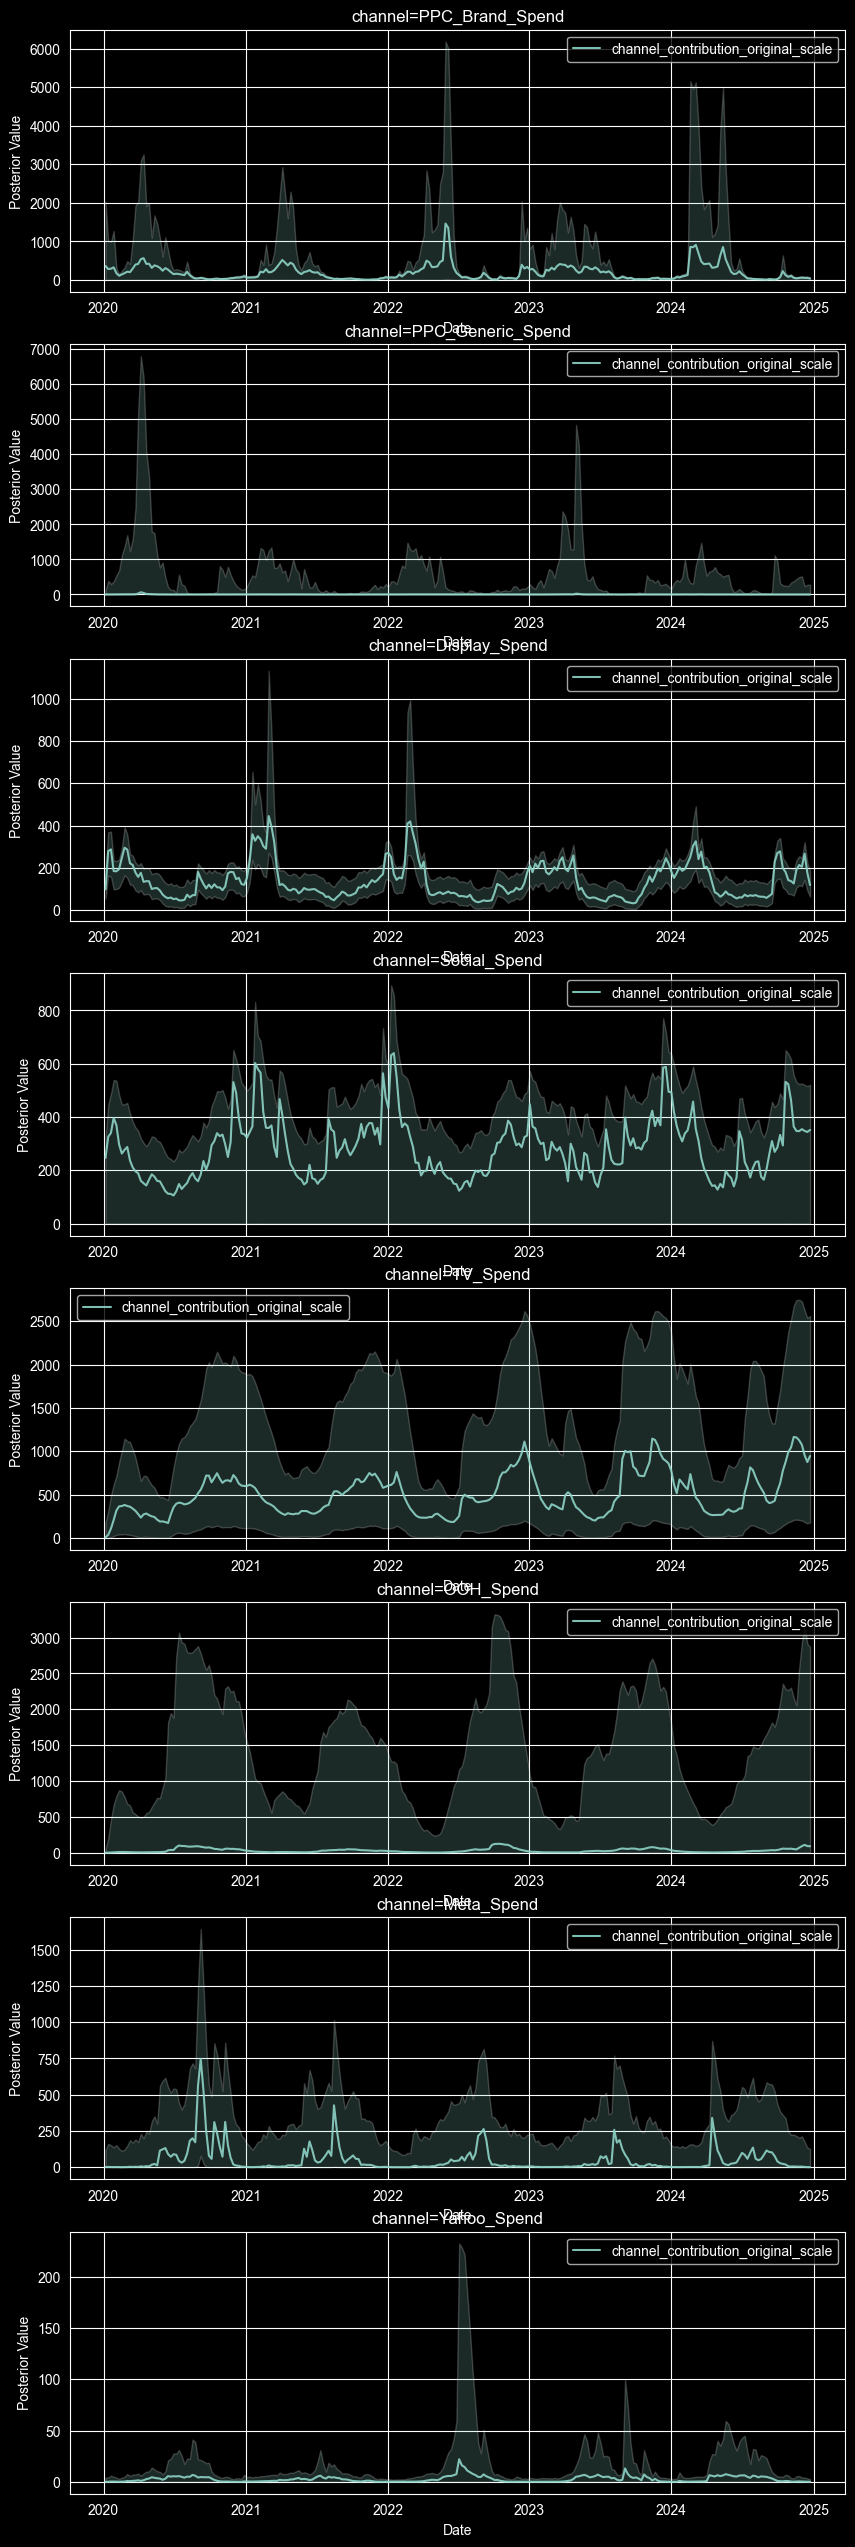

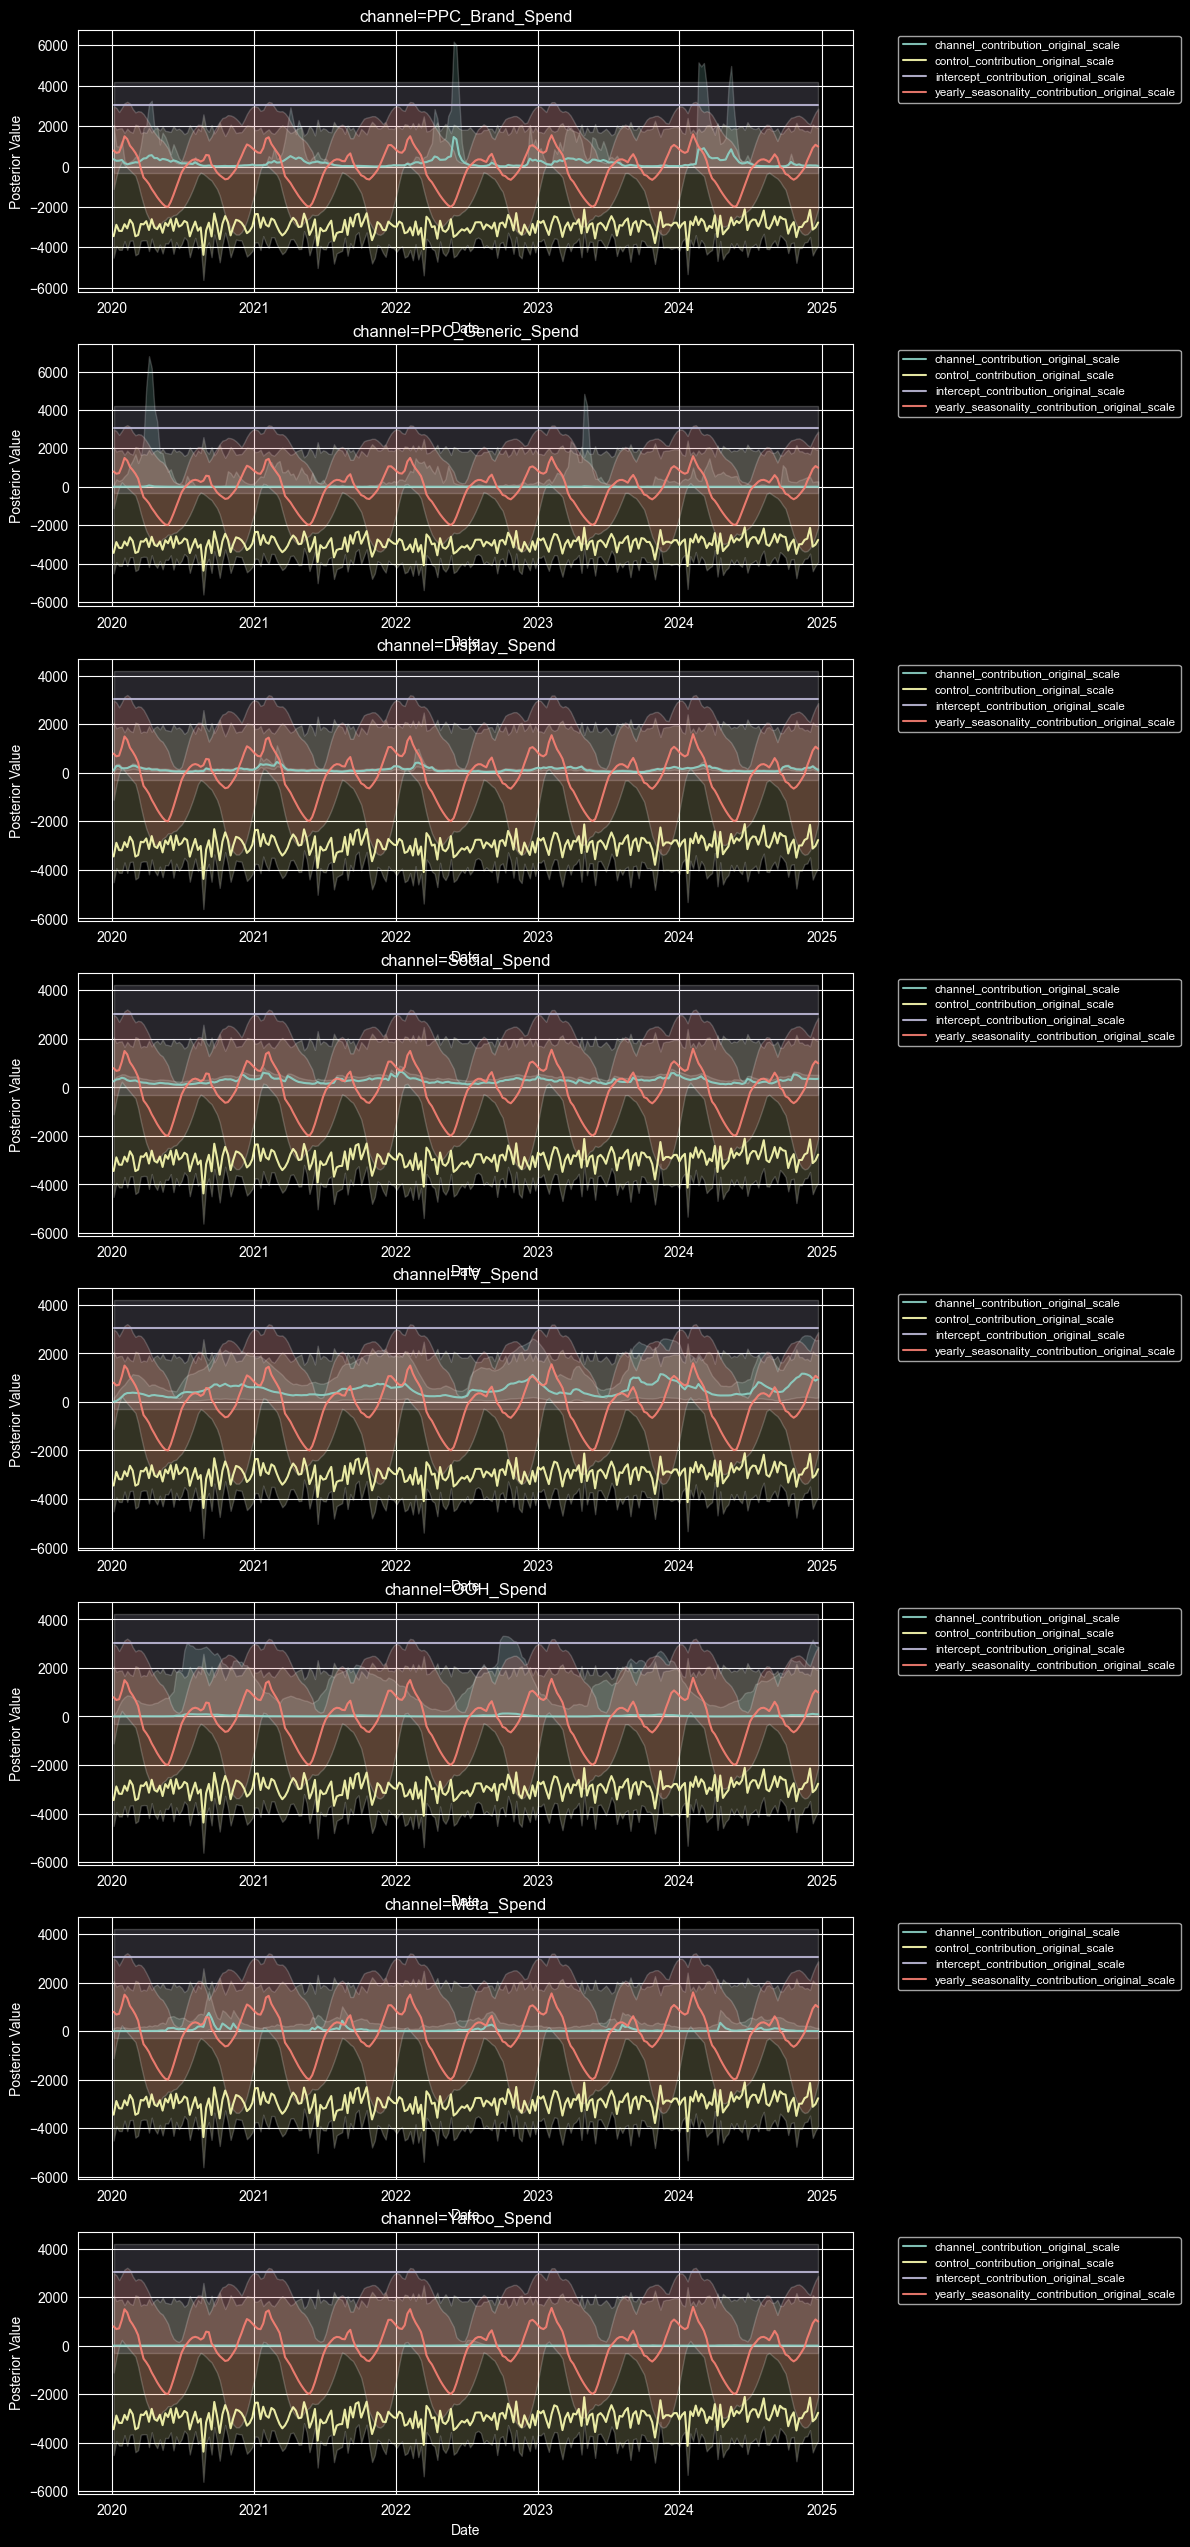

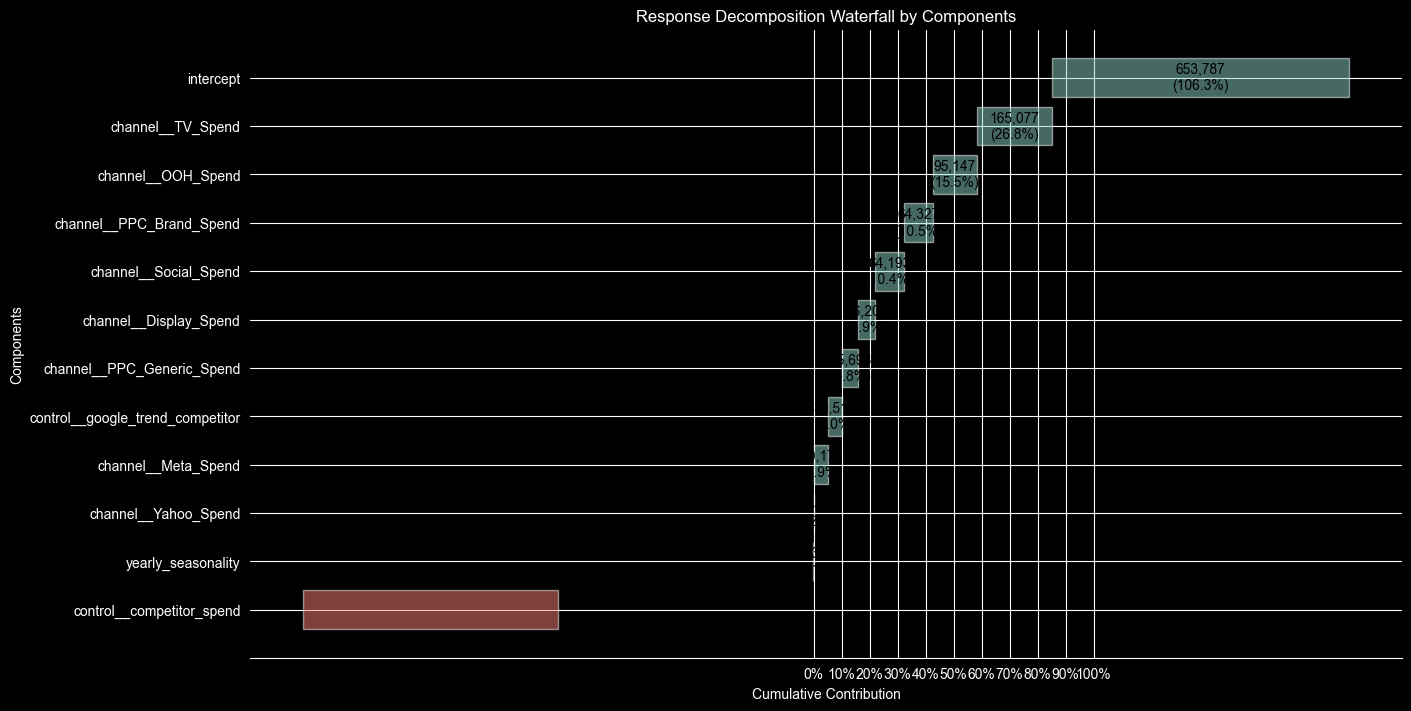

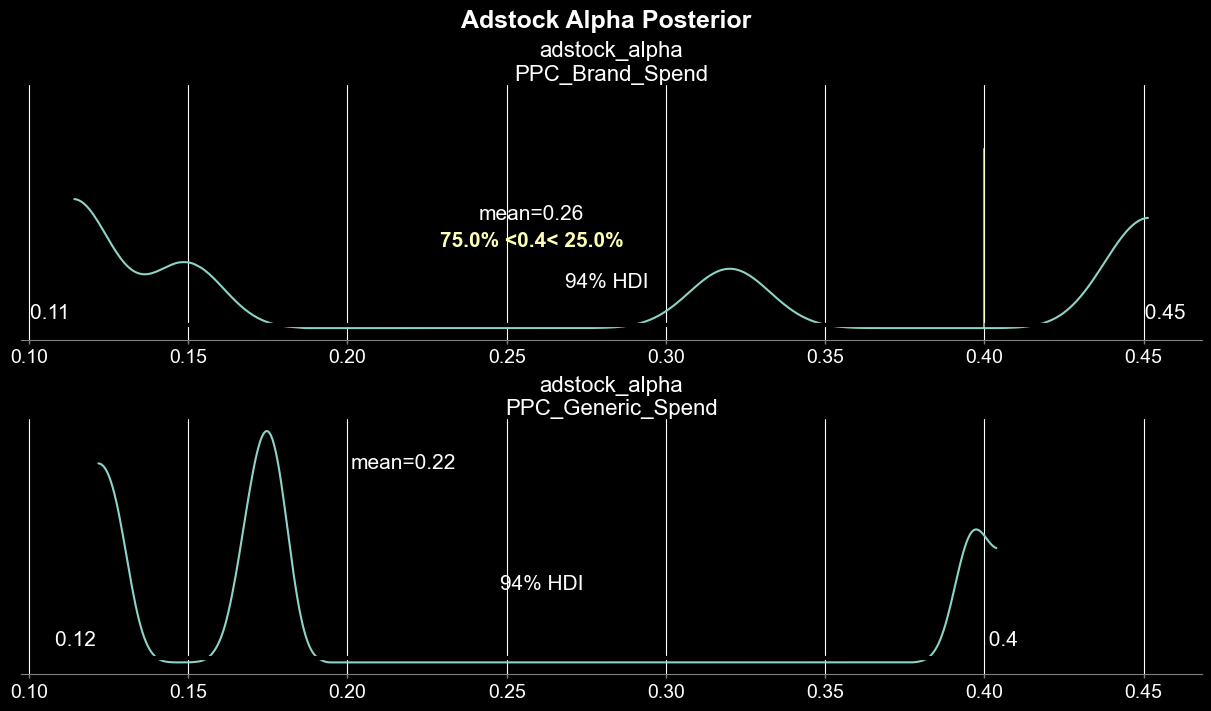

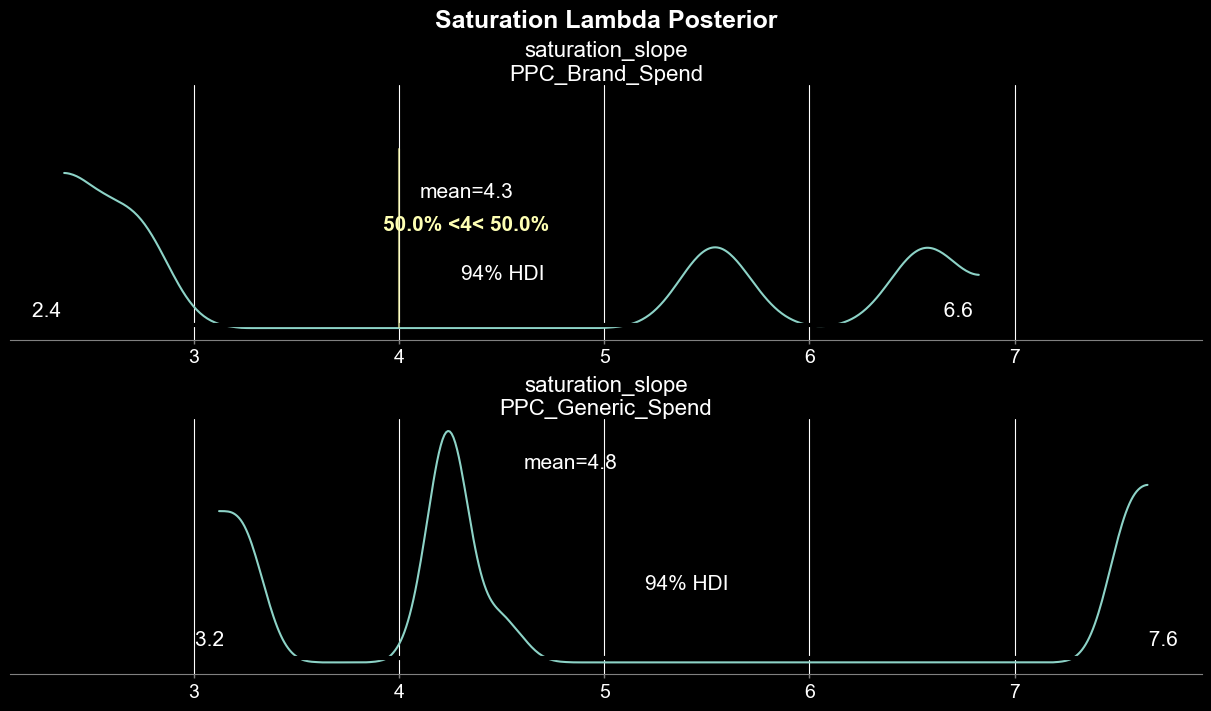

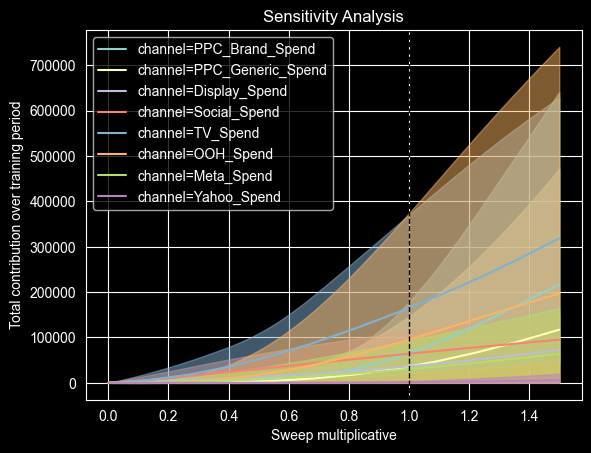

In [25]:
mmm_waterfall, mmm_contribution = mmm_model_predict(mmm, X, df)

In [26]:
import arviz as az
import matplotlib.pyplot as plt
from pymc_marketing.mmm.multidimensional import MMM


def mmm_roas(mmm: MMM):
    roas = mmm.incrementality.contribution_over_spend(frequency="all_time").rename(
        "roas"
    )

    all_channels = [
        "PPC_Brand_Spend",
        "PPC_Generic_Spend",
        "Display_Spend",
        "Social_Spend",
        "TV_Spend",
        "OOH_Spend",
        "Meta_Spend",
        "Yahoo_Spend",
    ]

    fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 12), layout="constrained")

    axes_flat = axes.flatten()

    for i, channel in enumerate(all_channels):
        channel_roas = roas.sel(channel=channel)

        az.plot_posterior(
            channel_roas, ax=axes_flat[i], hdi_prob=None, color="green", round_to=2
        )

        hdi_ds = az.hdi(channel_roas, hdi_prob=0.94)

        hdi_low = float(hdi_ds.to_array().values.flatten()[0])
        hdi_high = float(hdi_ds.to_array().values.flatten()[-1])

        axes_flat[i].hlines(
            y=0,
            xmin=hdi_low,
            xmax=hdi_high,
            color="red",
            linewidth=3,  # 特意加粗到 6，絕對看得到
            label="94% HDI",
        )

        axes_flat[i].text(
            hdi_low, 0.05, f"{hdi_low:.2f}", color="red", ha="center", weight="bold"
        )
        axes_flat[i].text(
            hdi_high, 0.05, f"{hdi_high:.2f}", color="red", ha="center", weight="bold"
        )

        title_ = channel.replace("_Spend", "") + " ROAS"
        axes_flat[i].set(title=title_)

        if i >= 6:
            axes_flat[i].set(xlabel="ROAS")

    fig.suptitle("ROAS Posterior Distributions", fontsize=18, fontweight="bold", y=1.06)

    return fig, axes

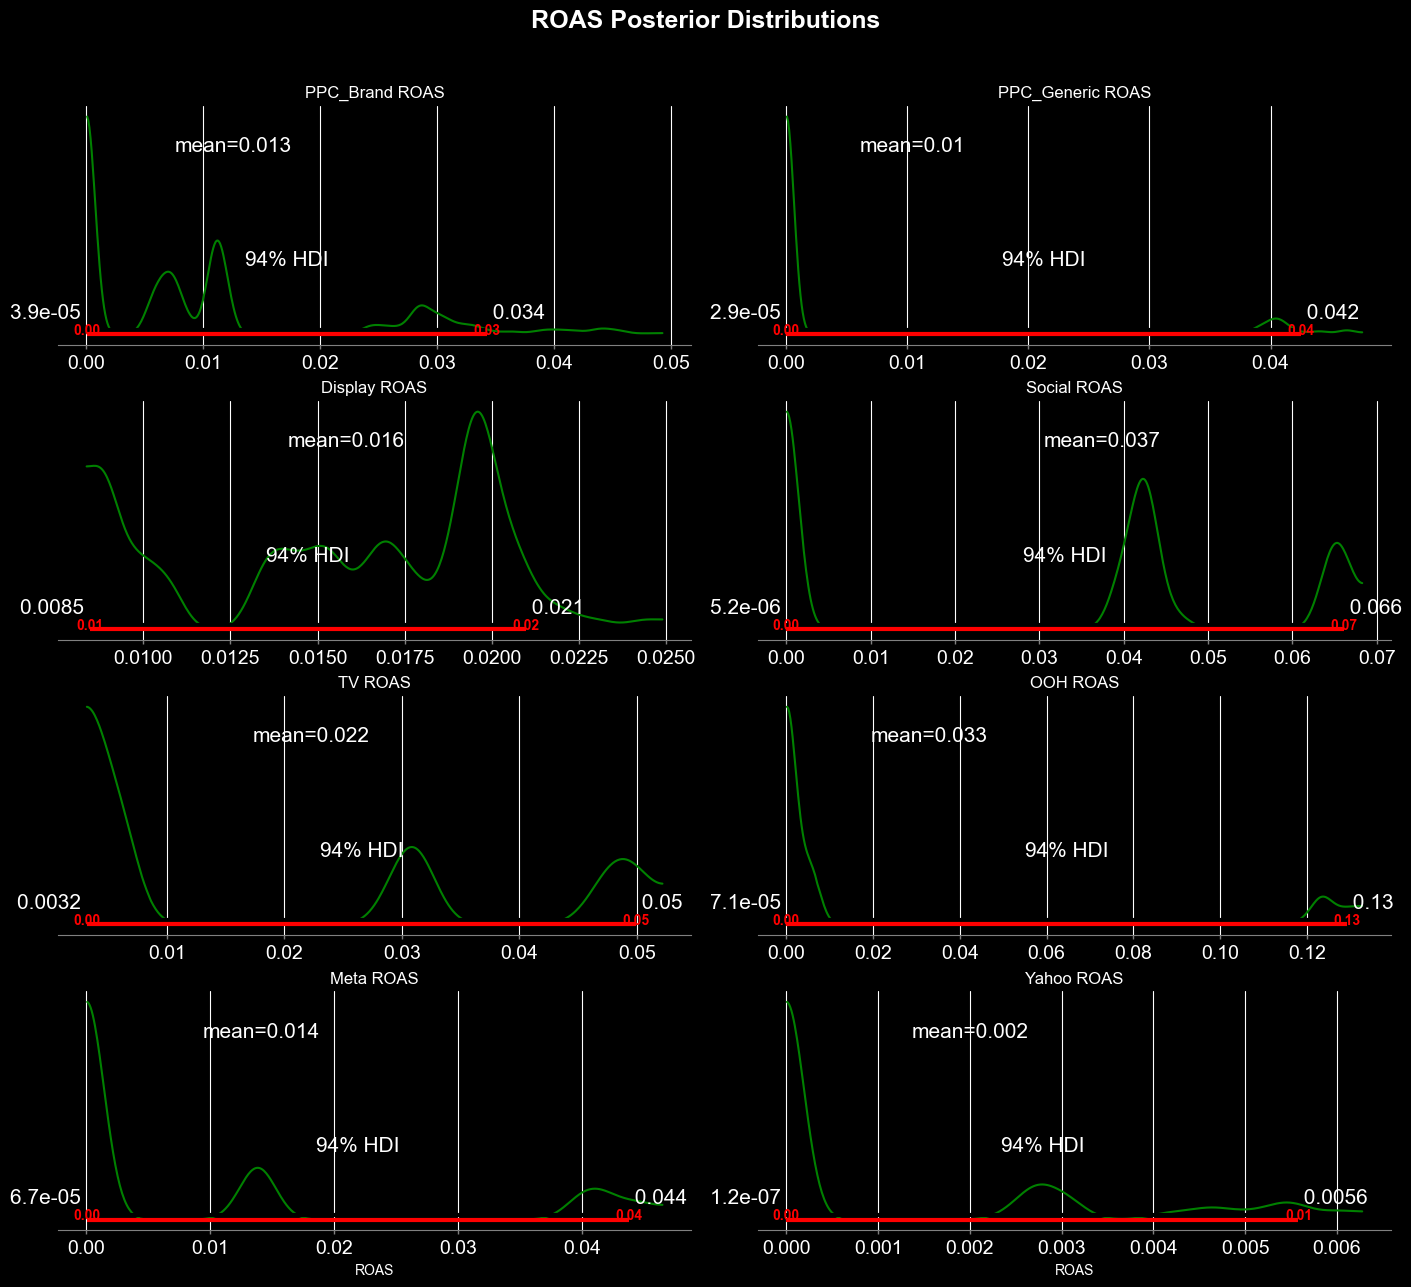

In [27]:
fig, axes = mmm_roas(mmm)

In [28]:
### Out of Sample Predictions
import pandas as pd
import numpy as np
import seaborn as sns
import arviz as az
import matplotlib.pyplot as plt
from pymc_marketing.mmm.multidimensional import MMM


def out_sample_predict(x: pd.DataFrame, y: pd.DataFrame, mmm: MMM, n_points: int = 15):

    last_date = x["date"].max()
    n_new = 5
    new_dates = pd.date_range(start=last_date, periods=1 + n_new, freq="W-MON")[1:]

    x_out_of_sample = pd.DataFrame({"date": new_dates})

    # channel spends, control vairable as last day
    all_channels = [
        "PPC_Brand_Spend",
        "PPC_Generic_Spend",
        "Display_Spend",
        "Social_Spend",
        "TV_Spend",
        "OOH_Spend",
        "Meta_Spend",
        "Yahoo_Spend",
    ]

    for ch in all_channels:
        x_out_of_sample[ch] = x[ch].iloc[-1]

    x_out_of_sample["competitor_spend"] = x["competitor_spend"].iloc[-1]
    x_out_of_sample["google_trend_competitor"] = x["google_trend_competitor"].iloc[-1]

    # predict future with include_last_observations is true, include Adstock lagging effect
    y_out_of_sample = mmm.sample_posterior_predictive(
        X=x_out_of_sample, extend_idata=False, include_last_observations=True
    )

    # Plot In sample
    fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")

    plot_x = pd.to_datetime(x["date"].iloc[-n_points:]).reset_index(drop=True)
    plot_y = y.iloc[-n_points:].reset_index(drop=True)

    if isinstance(plot_y, pd.DataFrame):
        plot_y = plot_y.iloc[:, 0]

    sns.lineplot(
        x=plot_x,
        y=plot_y,
        marker="o",
        markersize=7,
        color="blue",
        label="actuals",
        sort=False,
        ax=ax,
    )

    y_out_original_scale = (
        y_out_of_sample["y_original_scale"].unstack().transpose(..., "date")
    )
    az.plot_hdi(
        x_out_of_sample["date"].dt.to_pydatetime(),
        y_out_original_scale,
        smooth=False,
        fill_kwargs={"alpha": 0.25, "color": "C0"},
        ax=ax,
    )

    # plotting the line(mean) for prediction
    mean = y_out_original_scale.mean(dim=("chain", "draw"))
    mean.plot(
        ax=ax, marker="o", markersize=7, label="Forecast", color="C0", linestyle="--"
    )

    ax.set(ylabel="Original Target Scale (Opportunities")
    ax.set_title("Out of sample predictions for MMM", fontsize=18, fontweight="bold")

    ax.legend(loc="upper left")
    return x_out_of_sample, y_out_of_sample, fig

Sampling: [y]


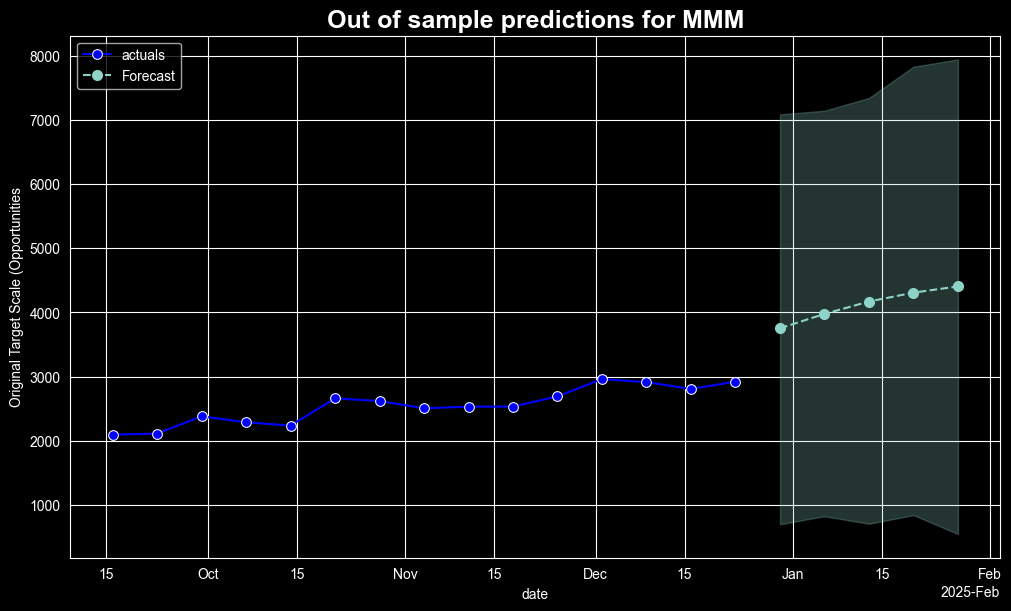

In [29]:
x_out, y_out, forecast_fig = out_sample_predict(X, y, mmm)

In [30]:
# mmm.save("model.nc", engine="h5netcdf")
# %load_ext watermark
# %watermark -n -u -v -iv -w -p pymc_marketing,pytensor